Import necessary packages:

In [1]:
from collections import deque
import itertools
from sage.all import *
from pysat.formula import *
from pysat.solvers import *

# Compute multiplication table for $B(n)$:

We use the matrix representation of $P$ from the Gardam paper (https://arxiv.org/abs/2312.05240), which makes solving the word problem in $P$ reduce to matrix multiplication over integer matrices.

In [2]:
K = GF(2)

# Cyclic group
C = CyclicPermutationGroup(7)

# Dihedral group (on an n-gon)
D = DihedralGroup(3)

# Promislow Group (known units of support length 21)
gens = [matrix(QQ, 4, [1, 0, 0, 1, 0, -1, 0, 1, 0, 0, -1, 0, 0, 0, 0, 1]), matrix(QQ, 4, [-1, 0, 0, 0, 0, 1, 0, 1, 0, 0, -1, 1, 0, 0, 0, 1])]
P = MatrixGroup(gens)

# Wreath Product, try Z wr Z_p, Z wr (Z_p x Z_q), lamplighter, try matrix representation
G1 = CyclicPermutationGroup(2)
G2 = CyclicPermutationGroup(3)
W = gap.StandardWreathProduct(gap(G1), gap(G2))

# UT_3(Z x Z_2), Heisenberg, SL_3(R)

# Surface group of genus g (Small cancellation C'(1/7))
# Note: need Knuth-Bendix implementation to get this working
def SurfaceGroup(g):
    """
    Create the surface group of genus g in GAP.
    The surface group has presentation:
    ⟨a₁,b₁,...,aₙ,bₙ | [a₁,b₁]...[aₙ,bₙ] = 1⟩
    where [a,b] = a⁻¹b⁻¹ab is the commutator.
    """
    if g < 0:
        raise ValueError("Genus must be non-negative")
    
    if g == 0:  # Sphere - trivial group
        return gap.TrivialGroup()
    
    # Create free group with 2g generators
    F = FreeGroup(2*g)
    
    # Get the generators
    gens = F.gens()
    
    # Construct the surface relation: [a₁,b₁][a₂,b₂]...[aₙ,bₙ] = 1
    relation = F.one()
    for i in range(1, g):
        a = gens[2*i-1]
        b = gens[2*i]
        commutator = a.inverse() * b.inverse() * a * b
        relation = relation * commutator
    
    # Create the group with the relation
    G = F / [relation,]
    
    return G

# Test if group is from GAP
def is_gap_object(obj):
    from sage.interfaces.gap import GapElement
    return isinstance(obj, GapElement)

# Creates ball of radius n for a GAP group
def create_ball_gap(G, n=5):
    symbols = [gap.One(G),] + list(gap.GeneratorsOfGroup(G)) + [gap.Inverse(A) for A in tuple(gap.GeneratorsOfGroup(G))]
    ball = [prod(word) for word in itertools.product(symbols, repeat=n)]
    ball = list(set(ball))
    return ball

# Creates ball of radius n for any group, GAP or Sage
def create_ball(G, n=5):
    if is_gap_object(G):
        return create_ball_gap(G, n)
    
    symbols = [G.one(),] + list(G.group_generators()) + [A.inverse() for A in G.group_generators()]
    ball = [prod(word) for word in itertools.product(symbols, repeat=n)]
    ball = list(set(ball))
    ball.remove(G.one())
    ball = [G.one(),] + ball
    return ball

G = DihedralGroup(5)
B = create_ball(G, 5)

In [3]:
def create_product_tables(B):
    """
    Creates the product tables given a ball of radius n.

    Input:
    B - the ball of radius n containing group elements

    Output:
    product_table - Python dict where keys are group elements, and values are lists of indices corresponding to factors
    factors_to_product - Python dict where keys are pairs, values are integers. Two keys map to the same integer if their products are the same.
    """
    # Keys are the product, values are lists of pairs realizing the product
    product_table = dict()
    
    factors_to_product = dict() # keys are pairs of indices, values are unique ids for the product. used for the gym environment.
    unique_id = 0
    for i,j in itertools.product(range(len(B)), repeat=2):
        a, b = B[i], B[j]
        val = a*b
        if val in product_table:
            product_table[val].append((i, j))
            factors_to_product[(i,j)] = factors_to_product[product_table[val][0]]
        else:
            product_table[val] = [(i,j),]
            factors_to_product[(i,j)] = unique_id
            unique_id += 1
    return product_table, factors_to_product

product_table, factors_to_product_specific = create_product_tables(B)
print(len(product_table))

10


# Reinforcement Learning Routine

Implements the `ZeroDivisorEnv` as well as the random search, DQN routine, and PPO routine.

In [4]:
import gymnasium as gym
import numpy as np
from gymnasium.spaces import Discrete, MultiBinary
import math

p = 2

class ZeroDivisorEnv(gym.Env):
    def __init__(self, N, factors_to_product):
        self.N = N
        self.factors_to_product = factors_to_product
        self.observation_space = MultiBinary(2*N)
        self.action_space = Discrete(2*(N - 1))
        self.alpha = np.zeros(self.N, dtype=np.uint8)
        self.alpha[0] = 1
        self.beta = np.zeros(self.N, dtype=np.uint8)
        self.beta[0] = 1

    def get_obs(self):
        return np.concatenate((self.alpha, self.beta))

    def get_info(self):
        return {"support_alpha": np.count_nonzero(self.alpha), "support_beta": np.count_nonzero(self.beta)}

    def reward(self):
        # -1 * support(alpha * beta) / (support(alpha) * support(beta))        
        return -1 * self.product_support() / (np.count_nonzero(self.alpha) * np.count_nonzero(self.beta))

    def product_support(self):
        product_dict = dict()
        for i in range(self.N):
            for j in range(self.N):
                if self.alpha[i] and self.beta[j]:
                    val = self.factors_to_product[(i,j)]
                    if val in product_dict:
                        product_dict[val] += 1
                    else:
                        product_dict[val] = 1

        support = 0
        for val in product_dict:
            support += (product_dict[val] % p)
        return support
    
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        
        self.alpha = np.zeros(self.N, dtype=np.uint8)
        self.alpha[0] = 1
        self.beta = np.zeros(self.N, dtype=np.uint8)
        self.beta[0] = 1
        
        observation = self.get_obs()
        info = self.get_info()

        # print(observation)

        return observation, info

    def step(self, action):
        if action < self.N - 1:
            self.alpha[action + 1] = (self.alpha[action + 1] + 1) % 2
        elif action >= self.N - 1:
            self.beta[action % (self.N - 1) + 1] = (self.beta[action % (self.N - 1) + 1] + 1) % 2

        reward = self.reward()
        
        terminated = True if reward == 0 else False
        truncated = True if np.count_nonzero(self.alpha) == 0 or np.count_nonzero(self.beta) == 0 else False
        
        
        observation = self.get_obs()
        info = self.get_info()

        return observation, reward, terminated, truncated, info
gym.register("ZeroDivisorEnv", ZeroDivisorEnv)

In [5]:
def random_search(G, n=5, n_envs=8, num_steps=10_000):
    """
    Implements a vectorized pure random search of the ZeroDivisorEnv. The action space is sampled uniformly.
    If an invalid action is taken in any of the environments, the actions are all chosen again.

    Inputs:
    G - the group (can be either a Sage group or a GAP group)
    n - the maximum length of a factor support element to consider
    n_envs - the number of environments to run in parallel
    num_steps - the number of actions to take in a given episode
    seed - the seed for resetting the environment

    Outputs:
    rewards - the vector of the final rewards at the end of the episode
    """
    
    B = create_ball(G, n)
    product_table, factors_to_product = create_product_tables(B)

    ball_size = len(B)
    vec_env = make_vec_env("ZeroDivisorEnv", n_envs=n_envs,
                           env_kwargs={"N": ball_size, "factors_to_product": factors_to_product})
    obs = vec_env.reset()

    eval_reward_vec = np.zeros(num_steps)
    
    for i in range(num_steps):
        actions = np.array([vec_env.action_space.sample() for _ in range(n_envs)])
        obs, rewards, dones, info = vec_env.step(actions)
        eval_reward_vec[i] = rewards[0]
        # print(info)
        invalid_steps = list(map(lambda info_single: info_single['support_alpha'] == 0 or info_single['support_beta'] == 0, info))
        for j in range(len(invalid_steps)):
            while invalid_steps[j]:
                actions = np.zeros(n_envs, dtype=np.uint32)
                actions[j] = int(vec_env.action_space.sample())
                # print("Resetting action: ", actions[i])
                obs, rewards, dones, info = vec_env.step(actions)

                if j == 0:
                    eval_reward_vec[i] = rewards[0]
                
                if info[j]['support_alpha'] != 0 and info[i]['support_beta'] != 0:
                    invalid_steps[j] = False
    vec_env.close()
    return rewards, eval_reward_vec

In [6]:
from stable_baselines3 import DQN, PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv, VecMonitor
from stable_baselines3.common import results_plotter
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.results_plotter import load_results, ts2xy, plot_results
from stable_baselines3.common.callbacks import BaseCallback

import matplotlib.pyplot as plt

class SaveOnBestTrainingRewardCallback(BaseCallback):
    """
    Callback for saving a model (the check is done every ``check_freq`` steps)
    based on the training reward (in practice, we recommend using ``EvalCallback``).

    Code from StableBaselines3 examples:
    https://stable-baselines3.readthedocs.io/en/master/guide/examples.html#callbacks-monitoring-training

    :param check_freq:
    :param log_dir: Path to the folder where the model will be saved.
      It must contain the file created by the ``Monitor`` wrapper.
    :param verbose: Verbosity level: 0 for no output, 1 for info messages, 2 for debug messages
    """
    def __init__(self, check_freq: int, log_dir: str, verbose: int = 1):
        super().__init__(verbose)
        self.check_freq = check_freq
        self.log_dir = log_dir
        self.save_path = os.path.join(log_dir, "best_model")
        self.best_mean_reward = -np.inf

    def _init_callback(self) -> None:
        # Create folder if needed
        if self.save_path is not None:
            os.makedirs(self.save_path, exist_ok=True)

    def _on_step(self) -> bool:
        if self.n_calls % self.check_freq == 0:

          # Retrieve training reward
          x, y = ts2xy(load_results(self.log_dir), "timesteps")
          if len(x) > 0:
              # Mean training reward over the last 100 episodes
              mean_reward = np.mean(y[-100:])
              if self.verbose >= 1:
                print(f"Num timesteps: {self.num_timesteps}")
                print(f"Best mean reward: {self.best_mean_reward:.2f} - Last mean reward per episode: {mean_reward:.2f}")

              # New best model, you could save the agent here
              if mean_reward > self.best_mean_reward:
                  self.best_mean_reward = mean_reward
                  # Example for saving best model
                  if self.verbose >= 1:
                    print(f"Saving new best model to {self.save_path}")
                  self.model.save(self.save_path)

        return True

def moving_average(values, window):
    """
    Smooth values by doing a moving average
    :param values: (numpy array)
    :param window: (int)
    :return: (numpy array)
    """
    weights = np.repeat(1.0, window) / window
    return np.convolve(values, weights, "valid")


def plot_results(log_folder, title="Learning Curve"):
    """
    plot the results

    :param log_folder: (str) the save location of the results to plot
    :param title: (str) the title of the task to plot
    """
    x, y = ts2xy(load_results(log_folder), "timesteps")
    y = moving_average(y, window=50)
    # Truncate x
    x = x[len(x) - len(y) :]

    fig = plt.figure(title)
    plt.plot(x, y)
    plt.xlabel("Number of Timesteps")
    plt.ylabel("Rewards")
    plt.title(title + " Smoothed")
    plt.show()

In [7]:
def dqn_search(G, n=5, num_steps=10_000, training_steps=25_000, dqn_kwargs = None):
    """
    Trains a DQN model on the ZeroDivisorEnv.

    Inputs:
    G - the group (can be either a Sage group or a GAP group)
    n - the maximum length of a factor support element to consider
    num_steps - the number of actions to take in a given episode
    training_steps - the number of steps to use for training
    dqn_kwargs (dict) - kwargs to pass to the StableBaselines DQN call

    Outputs:
    rewards - the vector of the final rewards at the end of the episode
    """
    log_dir = "tmp/dqn/"
    os.makedirs(log_dir, exist_ok=True)
    
    B = create_ball(G, n)
    product_table, factors_to_product = create_product_tables(B)

    ball_size = len(B)
    
    env = ZeroDivisorEnv(ball_size, factors_to_product)
    env = Monitor(env, log_dir)
    
    model = DQN("MlpPolicy", env, verbose=0, device="cuda", **dqn_kwargs)
    callback = SaveOnBestTrainingRewardCallback(check_freq=1000, log_dir=log_dir, verbose=1)

    print("DQN Train:")
    print("---------------------------------------")
    model.learn(total_timesteps=training_steps, callback=callback) #TODO: Add callback to get training and eval curves
    model.save("dqn_zerodivisor")

    try:    
        plot_results(log_dir, "DQN Training Curve")
    except:
        pass

    
    env.close()
    env = ZeroDivisorEnv(ball_size, factors_to_product)
    print("DQN Test Starts Now:")
    print("-------------------------------------------")
    obs, info = env.reset()

    eval_reward_vec = np.zeros(num_steps)
    
    for i in range(num_steps):
        action, _states = model.predict(obs, deterministic=True)
        obs, rewards, terminated, truncated, info = env.step(action)
        eval_reward_vec[i] = rewards

        if terminated:
            break
    env.close()
    
    return rewards, eval_reward_vec

In [8]:
def ppo_search(G, n=5, num_steps=10_000, training_steps=25_000, ppo_kwargs=None):
    """
    Trains a PPO model on the ZeroDivisorEnv.

    Inputs:
    G - the group (can be either a Sage group or a GAP group)
    n - the maximum length of a factor support element to consider
    num_steps - the number of actions to take in a given episode
    training_steps - the number of steps to use for training
    ppo_kwargs (dict) - kwargs to pass to the StableBaselines PPO call

    Outputs:
    rewards - the vector of the final rewards at the end of the episode
    """
    log_dir = "tmp/ppo/"
    os.makedirs(log_dir, exist_ok=True)
    
    B = create_ball(G, n)
    product_table, factors_to_product = create_product_tables(B)

    ball_size = len(B)
    env = ZeroDivisorEnv(ball_size, factors_to_product)
    env = Monitor(env, log_dir)

    model = PPO("MlpPolicy", env, verbose=0, device="cpu", **ppo_kwargs)
    callback = SaveOnBestTrainingRewardCallback(check_freq=1000, log_dir=log_dir, verbose=1)

    print("PPO Train:")
    print("---------------------------------------")
    model.learn(total_timesteps=training_steps, callback=callback)
    model.save("ppo_zerodivisor")

    try:    
        plot_results(log_dir, "PPO Training Curve")
    except:
        pass

    env.close()
    env = ZeroDivisorEnv(ball_size, factors_to_product)

    print("PPO Test Starts Now:")
    print("-------------------------------------------")
    obs, info = env.reset()

    eval_reward_vec = np.zeros(num_steps)
    
    for i in range(num_steps):
        action, _states = model.predict(obs, deterministic=True)
        obs, rewards, terminated, truncated, info = env.step(action)
        eval_reward_vec[i] = rewards

        if terminated:
            break
    env.close()
    return rewards, eval_reward_vec

# Hyperparameter Tuning

Uses the [Optuna](https://optuna.readthedocs.io/en/stable/index.html) package to automate hyperparameter tuning.

Code is adapted from [Antonin Raffin's code here.](https://gist.github.com/araffin/d16e77aa88ffc246856f4452ab8a2524) He also has a [great explanatory article](https://araffin.github.io/post/optuna/) on how the Optuna package and general automated hyperparameter sampling/pruning work.

In [9]:
import optuna

def sample_dqn_params(trial):
    """
    Sampler for DQN hyperparameters.
    
    Input:
    trial - optuna Trial object

    Output:
    dict of hyperparameters for DQN.
    """
    gamma = trial.suggest_float("gamma", 0.97, 0.9999)
    learning_rate = trial.suggest_float("learning_rate", 3e-5, 3e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
    train_freq = trial.suggest_int("train_freq", 2, 4)
    exploration_fraction = trial.suggest_float("exploration_fraction", 0.05, 0.5)

    # From 1k to 10mil
    # buffer_size_pow = trial.suggest_int("buffer_size_pow", 3, 7)

    # From 1k to 1mil
    # target_update_interval_pow = trial.suggest_int("target_update_interval_pow", 3, 6)
    
    # Convert power of two to number of steps
    # buffer_size = 10**buffer_size_pow
    # target_update_interval = 10**target_update_interval_pow
    
    # Display true values
    # trial.set_user_attr("buffer_size", buffer_size)
    # trial.set_user_attr("target_update_interval", target_update_interval)

    return {
        "gamma": gamma,
        "learning_rate": learning_rate,
        "batch_size": batch_size,
        # "buffer_size": buffer_size,
        "train_freq": train_freq,
        # "target_update_interval": target_update_interval,
        "exploration_fraction": exploration_fraction
    }

In [10]:
import torch
import torch.nn as nn

def sample_ppo_params(trial):
    """
    Sampler for PPO hyperparameters.
    
    Input:
    trial - optuna Trial object

    Output:
    dict of hyperparameters for PPO.
    """
     # From 2**5=32 to 2**12=4096
    n_steps_pow = trial.suggest_int("n_steps_pow", 5, 12)
    gamma = trial.suggest_float("gamma", 0.97, 0.9999)
    learning_rate = trial.suggest_float("learning_rate", 3e-5, 3e-3, log=True)
    activation_fn = trial.suggest_categorical("activation_fn", ["tanh", "relu"])
    gae_lambda = trial.suggest_float("gae_lambda", 0.9, 1)
    clip_range = trial.suggest_categorical("clip_range", [0.1, 0.2, 0.3])
    vf_coef = trial.suggest_categorical("vf_coef", [0.5, 1])
    ent_coef = trial.suggest_categorical("ent_coef", [0, 1e-4, 1e-3, 1e-2])
    target_kl = trial.suggest_float("target_kl", 0.003, 0.03)

    n_steps = 2**n_steps_pow
    # Display true values
    trial.set_user_attr("n_steps", n_steps)
    # Convert to PyTorch objects
    activation_fn = {"tanh": nn.Tanh, "relu": nn.ReLU}[activation_fn]

    return {
        "n_steps": n_steps,
        "gamma": gamma,
        "learning_rate": learning_rate,
        "gae_lambda": gae_lambda,
        "clip_range": clip_range,
        "vf_coef": vf_coef,
        "ent_coef": ent_coef,
        "target_kl": target_kl,
        "policy_kwargs": {
            "activation_fn": activation_fn,
        },
    }

In [11]:
from stable_baselines3.common.vec_env import VecEnv

def evaluate_policy(model, env, n_eval_steps = 0, n_eval_episodes = 10, deterministic = True, render = False, callback = None, reward_threshold = None,
                    return_episode_rewards = False):
    """
    Runs policy for ``n_eval_episodes`` episodes and returns average reward.
    This is made to work only with one env.

    :param model: (BaseRLModel) The RL agent you want to evaluate.
    :param env: (gym.Env or VecEnv) The gym environment. In the case of a ``VecEnv``
        this must contain only one environment.
    :param n_eval_steps: (int) Max number of steps to take in a given episode, set to 0 for no bound.
    :param n_eval_episodes: (int) Number of episode to evaluate the agent
    :param deterministic: (bool) Whether to use deterministic or stochastic actions
    :param render: (bool) Whether to render the environment or not
    :param callback: (callable) callback function to do additional checks,
        called after each step.
    :param reward_threshold: (float) Minimum expected reward per episode,
        this will raise an error if the performance is not met
    :param return_episode_rewards: (Optional[float]) If True, a list of reward per episode
        will be returned instead of the mean.
    :return: (float, float) Mean reward per episode, std of reward per episode
        returns ([float], [int]) when ``return_episode_rewards`` is True
    """
    if isinstance(env, VecEnv):
        assert env.num_envs == 1, "You must pass only one environment when using this function"

    episode_rewards, episode_lengths = [], []
    for i in range(n_eval_episodes):
        # Avoid double reset, as VecEnv are reset automatically
        if not isinstance(env, VecEnv) or i == 0:
            obs = env.reset()
        done, state = False, None
        episode_reward = -1.0
        episode_length = 0
        while not done and (n_eval_steps == 0 or episode_length < n_eval_steps):
            action, state = model.predict(obs, state=state, deterministic=deterministic)
            new_obs, reward, done, _info = env.step(action)
            obs = new_obs
            episode_reward = reward
            if callback is not None:
                callback(locals(), globals())
            episode_length += 1
            if render:
                env.render()
        episode_rewards.append(episode_reward)
        episode_lengths.append(episode_length)
    mean_reward = np.mean(episode_rewards)
    std_reward = np.std(episode_rewards)
    if reward_threshold is not None:
        assert mean_reward > reward_threshold, "Mean reward below threshold: {:.2f} < {:.2f}".format(mean_reward, reward_threshold)
    if return_episode_rewards:
        return episode_rewards, episode_lengths
    return mean_reward, std_reward

In [12]:
from stable_baselines3.common.vec_env import sync_envs_normalization
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback

import os

class TrialEvalCallback(EvalCallback):
    """
    Callback used for evaluating and reporting a trial.
    
    Will use a pruner from Optuna to stop a trial short if its performance is too low.

    Code from: https://araffin.github.io/post/optuna/
    """

    def __init__(
        self,
        eval_env,
        trial,
        n_eval_steps = 0,
        n_eval_episodes = 5,
        eval_freq = 10000,
        deterministic = True,
        verbose = 0,
    ):
        super().__init__(
            eval_env=eval_env,
            n_eval_episodes=n_eval_episodes,
            eval_freq=eval_freq,
            deterministic=deterministic,
            verbose=verbose,
            render=False
        )
        self.n_eval_steps = n_eval_steps
        self.trial = trial
        self.eval_idx = 0
        self.is_pruned = False
    
    def _on_step(self):
        if self.eval_freq > 0 and self.n_calls % self.eval_freq == 0:
            # Sync training and eval env if there is VecNormalize
            sync_envs_normalization(self.training_env, self.eval_env)

            episode_rewards, episode_lengths = evaluate_policy(self.model, self.eval_env,
                                                               n_eval_steps=self.n_eval_steps,
                                                               n_eval_episodes=self.n_eval_episodes,
                                                               render=self.render,
                                                               deterministic=self.deterministic,
                                                               return_episode_rewards=True)

            if self.log_path is not None:
                self.evaluations_timesteps.append(self.num_timesteps)
                self.evaluations_results.append(episode_rewards)
                self.evaluations_length.append(episode_lengths)
                np.savez(self.log_path, timesteps=self.evaluations_timesteps,
                         results=self.evaluations_results, ep_lengths=self.evaluations_length)

            mean_reward, std_reward = np.mean(episode_rewards), np.std(episode_rewards)
            mean_ep_length, std_ep_length = np.mean(episode_lengths), np.std(episode_lengths)
            # Keep track of the last evaluation
            self.last_mean_reward = mean_reward

            if self.verbose > 0:
                print("Eval num_timesteps={}, "
                      "episode_reward={:.4f} +/- {:.2f}".format(self.num_timesteps, mean_reward, std_reward))
                print("Episode length: {:.4f} +/- {:.2f}".format(mean_ep_length, std_ep_length))

            if mean_reward > self.best_mean_reward:
                if self.verbose > 0:
                    print("New best mean reward!")
                if self.best_model_save_path is not None:
                    self.model.save(os.path.join(self.best_model_save_path, 'best_model'))
                self.best_mean_reward = mean_reward

            self.eval_idx += 1
            self.trial.report(self.last_mean_reward, self.eval_idx)
            # Prune trial if need.
            if self.trial.should_prune():
                self.is_pruned = True
                return False
        return True

# RL Experiments

Experiments on various groups with the random and DQN/PPO searches. If you want to reproduce or play around with these experiments, run all of the above cells and configure the parameters below.

In [32]:
# TODO: TRPO & other stablebaselines3 agents, Early stopping, data storage, figure out what happened with PPO (replace Monitor code)
# Curriculum/Transfer learning (Use SAT Solver?)

import pandas as pd

# Group
# G = GroupSemidirectProduct(CyclicPermutationGroup(7), CyclicPermutationGroup(3))
G = CyclicPermutationGroup(29)
n = 15

B = create_ball(G, n)
product_table, factors_to_product = create_product_tables(B)

ball_size = len(B)
print("Ball Size: ", ball_size)

REWARD_THRESHOLD = 0
NUM_ENVS = 100 # Number of environments to run in parallel (think of as number of samples)
MAX_EPISODE_STEPS = 2 * ball_size # Number of steps for an eval episode
TRAINING_STEPS = 300_000 # Number of steps for training

# Optuna Parameters
N_TRIALS = 50 # Number of trials to consider
TIMEOUT = None # in seconds, None if we want to ensure N_TRIALS trials are actually run

N_ENVS_OPTUNA = 100 # Number of envs to run in parallel for Optuna tuning
N_TIMESTEPS = 50_000 # Training steps for model training during Optuna tuning
# each vec_env.step() is N_ENVS steps
EVAL_FREQ = 25_000 // N_ENVS_OPTUNA # Frequency for the eval callback in Optuna tuning
N_EVAL_STEPS = 2 * ball_size # Max number of steps to take per episode for Optuna tuning
N_EVAL_EPISODES = 1 # Number of eval episodes for Optuna tuning
N_EVALUATIONS = N_EVAL_EPISODES

# Choose specific RL algorithms to run
RUN_DQN = True
RUN_PPO = True

Ball Size:  29


In [33]:
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler, RandomSampler

def objective_dqn(trial, ball_size, factors_to_product):    
    # Create train and eval envs,
    vec_env = make_vec_env("ZeroDivisorEnv", n_envs=N_ENVS_OPTUNA, env_kwargs={"N": ball_size, "factors_to_product": factors_to_product})
    eval_env = make_vec_env("ZeroDivisorEnv", n_envs=1, env_kwargs={"N": ball_size, "factors_to_product": factors_to_product})
    # Sample hyperparameters. and create the RL model
    model = DQN("MlpPolicy", vec_env, verbose=0, device="cuda", **sample_dqn_params(trial))

    # Create the callback that will periodically evaluate and report the performance.
    eval_callback = TrialEvalCallback(
        eval_env,
        trial,
        n_eval_steps=N_EVAL_STEPS,
        n_eval_episodes=N_EVAL_EPISODES,
        eval_freq=EVAL_FREQ, 
        deterministic=True,
        verbose=1
    )
    # Train the RL agent
    nan_encountered = False
    try:
        print("Optuna model training begins now.")
        model.learn(N_TIMESTEPS, callback=eval_callback)
    except AssertionError as e:
        # Sometimes, random hyperparams can generate NaN.
        print(e)
        nan_encountered = True
    finally:
        # Free memory.
        model.env.close()
        eval_env.close()


    if eval_callback.is_pruned:
        raise optuna.exceptions.TrialPruned()
    # Report final performance
    return eval_callback.last_mean_reward

# Select the sampler, can be random, TPESampler, CMAES, ...
sampler = TPESampler(n_startup_trials=5, multivariate=True)
# Do not prune before 1/3 of the max budget is used
pruner = MedianPruner(n_startup_trials=5, n_warmup_steps=N_EVALUATIONS // 3)
	
# Create the study and start the hyperparameter optimization
study = optuna.create_study(sampler=sampler, pruner=pruner, direction="maximize")
try:
    zero_divisor_objective_dqn = lambda trial: objective_dqn(trial, ball_size, factors_to_product)
    study.optimize(zero_divisor_objective_dqn, n_trials=N_TRIALS, timeout=TIMEOUT, n_jobs=1)
except KeyboardInterrupt:
    pass
# This script can be launch in parallel when using a database
# We pass the objective function defined previously
# Best result
best_trial_dqn = study.best_trial

print(f"Number of finished trials: {len(study.trials)}")

print("Best trial:")
trial = study.best_trial

print("  Value: ", trial.value)

print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

print("  User attrs:")
for key, value in trial.user_attrs.items():
    print(f"    {key}: {value}")

/home/amazin/miniforge3/envs/sage/lib/python3.12/site-packages/optuna/_experimental.py:31: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2025-06-22 10:09:29,047] A new study created in memory with name: no-name-a084d6ce-bced-4518-bf28-18e791150987


Optuna model training begins now.


/home/amazin/miniforge3/envs/sage/lib/python3.12/site-packages/gymnasium/envs/registration.py:736: UserWarning: WARN: The environment is being initialised with render_mode='rgb_array' that is not in the possible render_modes ([]).
  logger.warn(


Eval num_timesteps=25000, episode_reward=-1.0000 +/- 0.00
Episode length: 58.0000 +/- 0.00
New best mean reward!


[I 2025-06-22 10:09:36,044] Trial 0 finished with value: -1.0 and parameters: {'gamma': 0.9823909281566742, 'learning_rate': 0.00029683096529306883, 'batch_size': 64, 'train_freq': 3, 'exploration_fraction': 0.22573794105179645}. Best is trial 0 with value: -1.0.


...

Eval num_timesteps=50000, episode_reward=-1.0000 +/- 0.00
Episode length: 58.0000 +/- 0.00
Optuna model training begins now.
Eval num_timesteps=25000, episode_reward=-1.0000 +/- 0.00
Episode length: 58.0000 +/- 0.00
New best mean reward!


[I 2025-06-22 10:15:51,439] Trial 48 finished with value: -0.5 and parameters: {'gamma': 0.9930743596435218, 'learning_rate': 0.0004983362606673477, 'batch_size': 128, 'train_freq': 3, 'exploration_fraction': 0.36990163450761504}. Best is trial 48 with value: -0.5.


Eval num_timesteps=50000, episode_reward=-0.5000 +/- 0.00
Episode length: 58.0000 +/- 0.00
New best mean reward!
Optuna model training begins now.
Eval num_timesteps=25000, episode_reward=-1.0000 +/- 0.00
Episode length: 58.0000 +/- 0.00
New best mean reward!


[I 2025-06-22 10:16:01,263] Trial 49 finished with value: -1.0 and parameters: {'gamma': 0.993755122690721, 'learning_rate': 0.00043074003839001153, 'batch_size': 128, 'train_freq': 3, 'exploration_fraction': 0.3539994454715899}. Best is trial 48 with value: -0.5.


Eval num_timesteps=50000, episode_reward=-1.0000 +/- 0.00
Episode length: 58.0000 +/- 0.00
Number of finished trials: 50
Best trial:
  Value:  -0.5
  Params: 
    gamma: 0.9930743596435218
    learning_rate: 0.0004983362606673477
    batch_size: 128
    train_freq: 3
    exploration_fraction: 0.36990163450761504
  User attrs:


In [34]:
def objective_ppo(trial, ball_size, factors_to_product):    
    # Create train and eval envs,
    vec_env = make_vec_env("ZeroDivisorEnv", n_envs=N_ENVS_OPTUNA, env_kwargs={"N": ball_size, "factors_to_product": factors_to_product})
    eval_env = make_vec_env("ZeroDivisorEnv", n_envs=1, env_kwargs={"N": ball_size, "factors_to_product": factors_to_product})
    # Sample hyperparameters. and create the RL model
    model = PPO("MlpPolicy", vec_env, verbose=0, device="cpu", **sample_ppo_params(trial))

    # Create the callback that will periodically evaluate and report the performance.
    eval_callback = TrialEvalCallback(
        eval_env,
        trial,
        n_eval_steps=N_EVAL_STEPS,
        n_eval_episodes=N_EVAL_EPISODES,
        eval_freq=EVAL_FREQ, 
        deterministic=True,
        verbose=1
    )
    # Train the RL agent
    nan_encountered = False
    try:
        print("Optuna model training begins now.")
        model.learn(N_TIMESTEPS, callback=eval_callback)
    except AssertionError as e:
        # Sometimes, random hyperparams can generate NaN.
        print(e)
        nan_encountered = True
    finally:
        # Free memory.
        model.env.close()
        eval_env.close()


    if eval_callback.is_pruned:
        raise optuna.exceptions.TrialPruned()
    # Report final performance
    return eval_callback.last_mean_reward

# Select the sampler, can be random, TPESampler, CMAES, ...
sampler = TPESampler(n_startup_trials=5, multivariate=True)
# Do not prune before 1/3 of the max budget is used
pruner = MedianPruner(n_startup_trials=5, n_warmup_steps=N_EVALUATIONS // 3)
	
# Create the study and start the hyperparameter optimization
study = optuna.create_study(sampler=sampler, pruner=pruner, direction="maximize")
try:
    zero_divisor_objective_ppo = lambda trial: objective_ppo(trial, ball_size, factors_to_product)
    study.optimize(zero_divisor_objective_ppo, n_trials=N_TRIALS, timeout=TIMEOUT, n_jobs=1)
except KeyboardInterrupt:
    pass
# This script can be launch in parallel when using a database
# We pass the objective function defined previously
# Best result
best_trial_ppo = study.best_trial

print(f"Number of finished trials: {len(study.trials)}")

print("Best trial:")
trial = study.best_trial

print("  Value: ", trial.value)

print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

print("  User attrs:")
for key, value in trial.user_attrs.items():
    print(f"    {key}: {value}")

[I 2025-06-22 10:16:01,273] A new study created in memory with name: no-name-65e9ec65-bd7a-4b44-898e-90fce18ccde1


Optuna model training begins now.
Eval num_timesteps=25000, episode_reward=-1.0000 +/- 0.00
Episode length: 58.0000 +/- 0.00
New best mean reward!
Eval num_timesteps=50000, episode_reward=-0.6667 +/- 0.00
Episode length: 58.0000 +/- 0.00
New best mean reward!


[I 2025-06-22 10:16:23,452] Trial 0 finished with value: -0.6666666865348816 and parameters: {'n_steps_pow': 7, 'gamma': 0.985988635220955, 'learning_rate': 3.786373729075071e-05, 'activation_fn': 'relu', 'gae_lambda': 0.9666276672173149, 'clip_range': 0.1, 'vf_coef': 0.5, 'ent_coef': 0.01, 'target_kl': 0.028059926801348122}. Best is trial 0 with value: -0.6666666865348816.


Optuna model training begins now.
Eval num_timesteps=25000, episode_reward=-1.0000 +/- 0.00
Episode length: 58.0000 +/- 0.00
New best mean reward!
Eval num_timesteps=50000, episode_reward=-0.2381 +/- 0.00
Episode length: 58.0000 +/- 0.00
New best mean reward!


[I 2025-06-22 10:16:49,608] Trial 1 finished with value: -0.2380952388048172 and parameters: {'n_steps_pow': 5, 'gamma': 0.988883558849882, 'learning_rate': 6.299142685733555e-05, 'activation_fn': 'tanh', 'gae_lambda': 0.9169569215350252, 'clip_range': 0.2, 'vf_coef': 1, 'ent_coef': 0.001, 'target_kl': 0.022992218794245112}. Best is trial 1 with value: -0.2380952388048172.


...

Optuna model training begins now.
Eval num_timesteps=25000, episode_reward=-1.0000 +/- 0.00
Episode length: 58.0000 +/- 0.00
New best mean reward!
Eval num_timesteps=50000, episode_reward=-0.0963 +/- 0.00
Episode length: 58.0000 +/- 0.00
New best mean reward!


[I 2025-06-22 10:33:53,034] Trial 48 finished with value: -0.0962962955236435 and parameters: {'n_steps_pow': 6, 'gamma': 0.9855536648831072, 'learning_rate': 0.0008319925256842078, 'activation_fn': 'tanh', 'gae_lambda': 0.9435088367825951, 'clip_range': 0.1, 'vf_coef': 0.5, 'ent_coef': 0.0001, 'target_kl': 0.018328940968788107}. Best is trial 27 with value: -0.05263157933950424.


Optuna model training begins now.
Eval num_timesteps=25000, episode_reward=-1.0000 +/- 0.00
Episode length: 58.0000 +/- 0.00
New best mean reward!


[I 2025-06-22 10:34:14,516] Trial 49 pruned. 


Eval num_timesteps=50000, episode_reward=-1.0000 +/- 0.00
Episode length: 58.0000 +/- 0.00
Number of finished trials: 50
Best trial:
  Value:  -0.05263157933950424
  Params: 
    n_steps_pow: 5
    gamma: 0.9963468764495215
    learning_rate: 0.0003402197448263406
    activation_fn: tanh
    gae_lambda: 0.9247370922763182
    clip_range: 0.2
    vf_coef: 1
    ent_coef: 0.0001
    target_kl: 0.027595319156036274
  User attrs:
    n_steps: 32


Random Search Avg:  -0.08739316


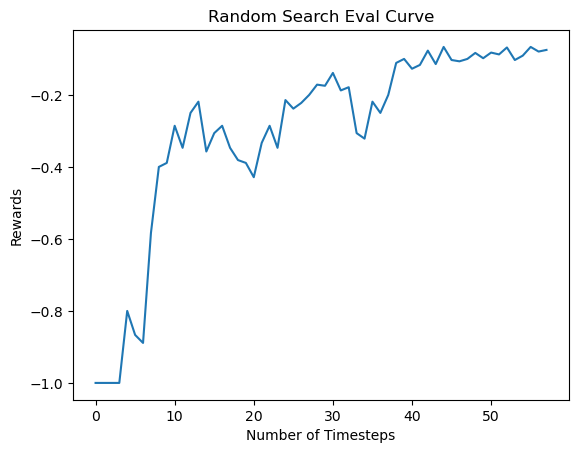

In [35]:
seed = np.random.randint(0, 2 ** 32 - 1)

rand, rand_eval_rewards = random_search(G, n, n_envs=NUM_ENVS, num_steps=MAX_EPISODE_STEPS)
print("Random Search Avg: ", np.average(rand))

def plot_results_from_array(arr, title="Learning Curve", moving_avg=True):
    """
    plot the results

    :param arr: (iterable) the array of rewards to plot
    :param title: (str) the title of the task to plot
    """
    x, y = list(range(len(arr))), arr
    if moving_avg:
        y = moving_average(y, window=50)
    # Truncate x
    x = x[len(x) - len(y) :]

    fig = plt.figure(title)
    plt.plot(x, y)
    plt.xlabel("Number of Timesteps")
    plt.ylabel("Rewards")
    if moving_avg:
        title = title + "Smoothed"
    plt.title(title)
    plt.show()

plot_results_from_array(rand_eval_rewards, "Random Search Eval Curve", moving_avg=False)

Note: Training curves take the sum of all rewards over a given episode.

DQN Train:
---------------------------------------
Num timesteps: 96000
Best mean reward: -inf - Last mean reward per episode: -4271.21
Saving new best model to tmp/dqn/best_model
Num timesteps: 97000
Best mean reward: -4271.21 - Last mean reward per episode: -4271.21
Num timesteps: 98000
Best mean reward: -4271.21 - Last mean reward per episode: -4271.21
Num timesteps: 99000
Best mean reward: -4271.21 - Last mean reward per episode: -4271.21
Num timesteps: 100000
Best mean reward: -4271.21 - Last mean reward per episode: -2215.62
Saving new best model to tmp/dqn/best_model
Num timesteps: 101000
Best mean reward: -2215.62 - Last mean reward per episode: -2215.62
Num timesteps: 102000
Best mean reward: -2215.62 - Last mean reward per episode: -2215.62
Num timesteps: 103000
Best mean reward: -2215.62 - Last mean reward per episode: -2215.62
Num timesteps: 104000
Best mean reward: -2215.62 - Last mean reward per episode: -2215.62
Num timesteps: 105000
Best mean reward: -2215.62 - Last mea

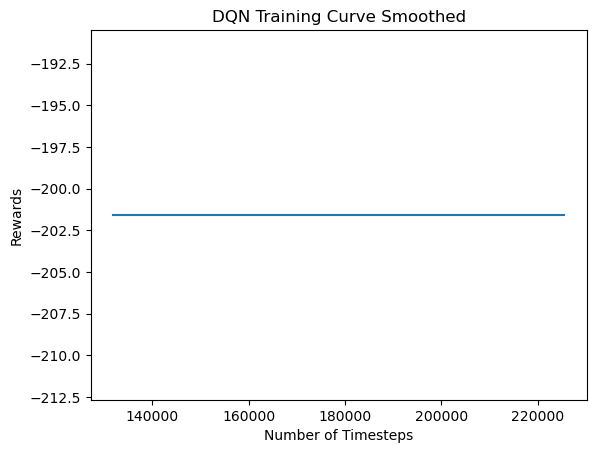

DQN Test Starts Now:
-------------------------------------------
DQN Avg:  -0.2244897959183673
% Diff Avg DQN:  -156.87342482135264


In [36]:
dqn_kwargs = dict()

if RUN_DQN:
    dqn_kwargs['learning_rate'] = best_trial_dqn.params['learning_rate']
    dqn_kwargs['batch_size'] = best_trial_dqn.params['batch_size']
    dqn_kwargs['gamma'] = best_trial_dqn.params['gamma']
    dqn_kwargs['exploration_fraction'] = best_trial_dqn.params['exploration_fraction']
    dqn_kwargs['train_freq'] = best_trial_dqn.params['train_freq']
    dqn_kwargs['target_update_interval'] = 10_000

    dqn, dqn_eval_rewards = dqn_search(G, n, num_steps=MAX_EPISODE_STEPS, training_steps=TRAINING_STEPS, dqn_kwargs=dqn_kwargs)
    dqn = [dqn for _ in range(NUM_ENVS)]
else:
    dqn, dqn_eval_rewards = [-1.0 for _ in range(NUM_ENVS)], []

print("DQN Avg: ", np.average(dqn))
print("% Diff Avg DQN: ", (np.average(rand) - np.average(dqn)) / np.average(rand) * 100)
percent_diff_dqn = (rand - dqn) / rand * 100

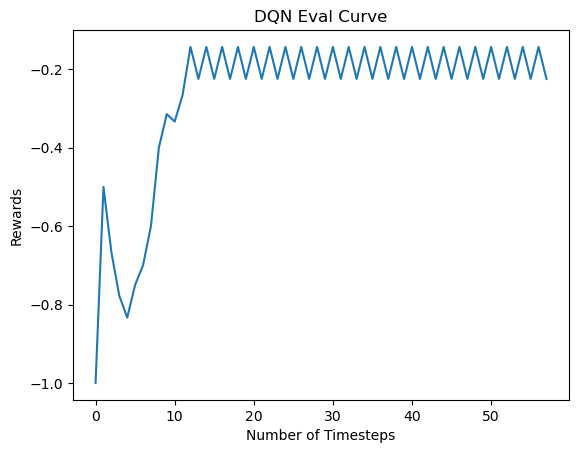

In [37]:
plot_results_from_array(dqn_eval_rewards, "DQN Eval Curve", moving_avg=False)

In [38]:
ppo_kwargs = dict()

if RUN_PPO:
    ppo_kwargs['learning_rate'] = best_trial_ppo.params['learning_rate']
    ppo_kwargs['gamma'] = best_trial_ppo.params['gamma']
    ppo_kwargs['n_steps'] = best_trial_ppo.user_attrs['n_steps']
    ppo_kwargs['batch_size'] = ppo_kwargs['n_steps']
    activation_fn = {"tanh": nn.Tanh, "relu": nn.ReLU}[best_trial_ppo.params['activation_fn']]
    ppo_kwargs['policy_kwargs'] = {'activation_fn': activation_fn,}
    ppo_kwargs['gae_lambda'] = best_trial_ppo.params['gae_lambda']
    ppo_kwargs['clip_range'] = best_trial_ppo.params['clip_range']
    ppo_kwargs['vf_coef'] = best_trial_ppo.params['vf_coef']
    ppo_kwargs['ent_coef'] = best_trial_ppo.params['ent_coef']
    ppo_kwargs['target_kl'] = best_trial_ppo.params['target_kl']
    
    ppo, ppo_eval_rewards = ppo_search(G, n, num_steps=MAX_EPISODE_STEPS, training_steps=TRAINING_STEPS, ppo_kwargs=ppo_kwargs)
    ppo = [ppo for _ in range(NUM_ENVS)]
else:
    ppo, ppo_eval_rewards = [-1.0 for _ in range(NUM_ENVS)], []

percent_diff_ppo = (rand - ppo) / rand * 100
print("PPO Avg: ", np.average(ppo))
print ("% Diff Avg PPO: ", (np.average(rand) - np.average(ppo)) / np.average(rand) * 100)

PPO Train:
---------------------------------------
PPO Test Starts Now:
-------------------------------------------
PPO Avg:  -1.0
% Diff Avg PPO:  -1044.2543469314803


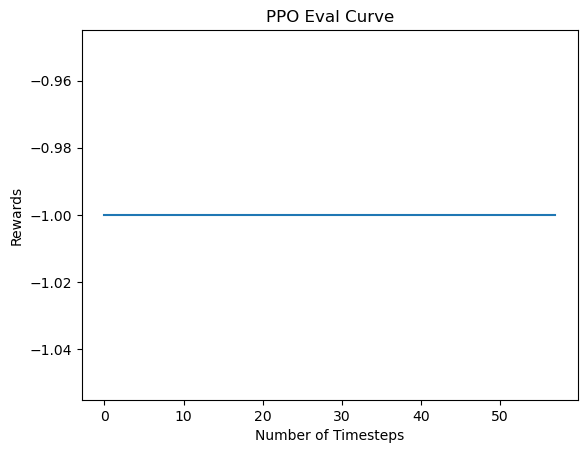

In [39]:
plot_results_from_array(ppo_eval_rewards, "PPO Eval Curve", moving_avg=False)

In [40]:
rewards_dict = {"Random_Search": rand, "DQN": dqn, "% Difference DQN": percent_diff_dqn, "PPO": ppo, "% Difference PPO": percent_diff_ppo}


df = pd.DataFrame(data=rewards_dict)
df

,Random_Search,DQN,% Difference DQN,PPO,% Difference PPO
0,-0.075000,-0.22449,-199.319716,-1.0,-1233.333280
1,-0.095238,-0.22449,-135.714281,-1.0,-949.999980
2,-0.087179,-0.22449,-157.502995,-1.0,-1047.058794
3,-0.133333,-0.22449,-68.367338,-1.0,-649.999961
4,-0.062500,-0.22449,-259.183673,-1.0,-1500.000000
...,...,...,...,...,...
95,-0.048889,-0.22449,-359.183680,-1.0,-1945.454574
96,-0.069444,-0.22449,-223.265291,-1.0,-1339.999931
97,-0.140741,-0.22449,-59.505912,-1.0,-610.526333
98,-0.100000,-0.22449,-124.489793,-1.0,-899.999985


In [41]:
df.query('Random_Search == 0')

,Random_Search,DQN,% Difference DQN,PPO,% Difference PPO


In [42]:
df.query('DQN == 0')

,Random_Search,DQN,% Difference DQN,PPO,% Difference PPO


In [43]:
df.query('PPO == 0')

,Random_Search,DQN,% Difference DQN,PPO,% Difference PPO


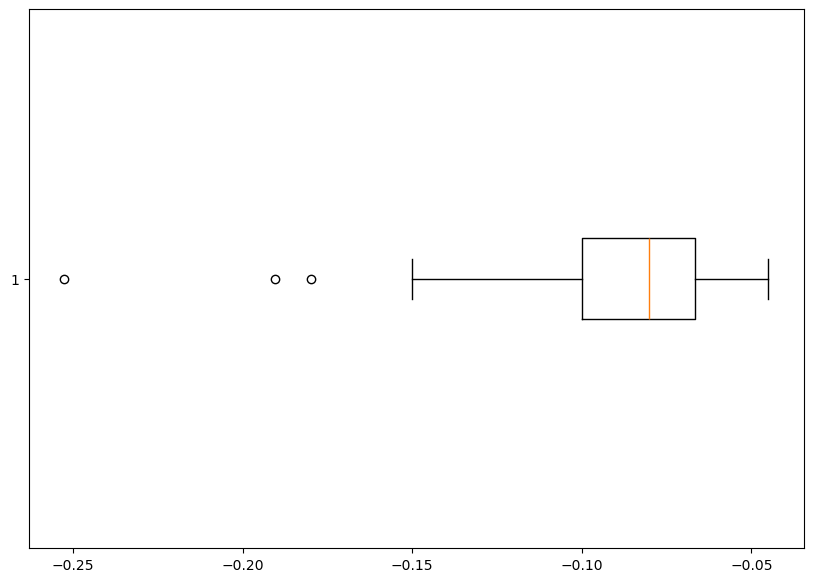

In [44]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize =(10, 7))

plt.boxplot(rand, orientation='horizontal')
plt.show()

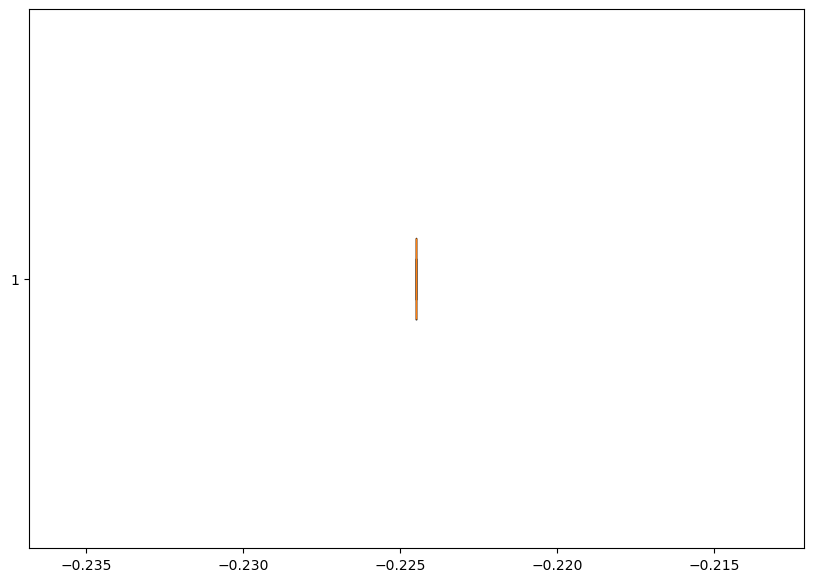

In [45]:
fig = plt.figure(figsize =(10, 7))

plt.boxplot(dqn, orientation='horizontal')
plt.show()

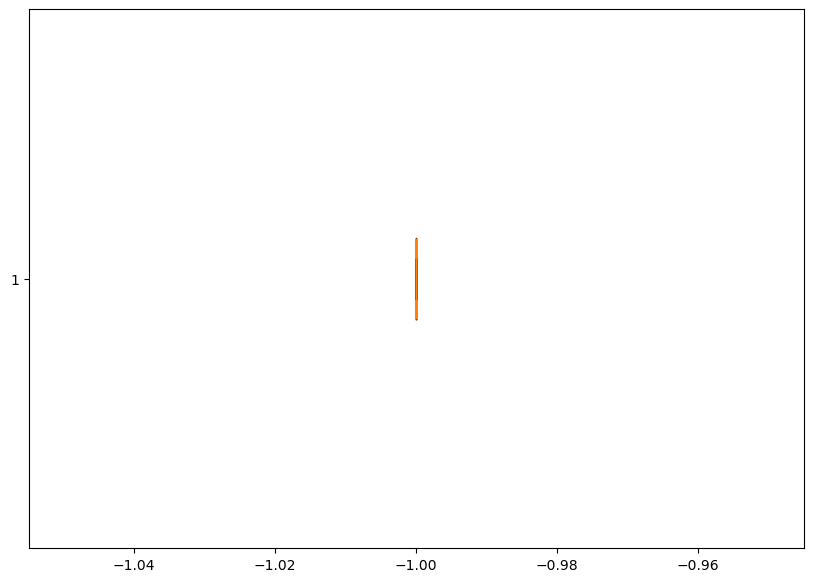

In [46]:
fig = plt.figure(figsize =(10, 7))

plt.boxplot(ppo, orientation='horizontal')
plt.show()

In [47]:
from stable_baselines3.common.vec_env import DummyVecEnv

vec_env = make_vec_env(ZeroDivisorEnv, n_envs=1, vec_env_cls=DummyVecEnv, env_kwargs={"N": ball_size, "factors_to_product": factors_to_product})
model = DQN.load("dqn_zerodivisor")

obs = vec_env.reset()
rewards = -1.0
ep_length = 0
while rewards != 0 and (N_EVAL_STEPS == 0 or ep_length < N_EVAL_STEPS):
    action, _states = model.predict(obs, deterministic=True)
    obs, rewards, dones, info = vec_env.step(action)
    ep_length += 1
print("Episode Length: ", ep_length)
if dones:
    best_pair = info[0]['terminal_observation']
else:
    best_pair = obs[0]
alpha = best_pair[:ball_size]
beta = best_pair[ball_size:]

alpha_str = "1"
beta_str = "1"

for i in range(1, ball_size):
    if alpha[i]:
        alpha_str = alpha_str + " + " + str(B[i])
    if beta[i]:
        beta_str = beta_str + " + " + str(B[i])

print("Alpha: ", alpha_str)
print("Beta: ", beta_str)

Episode Length:  58
Alpha:  1 + (1,23,16,9,2,24,17,10,3,25,18,11,4,26,19,12,5,27,20,13,6,28,21,14,7,29,22,15,8) + (1,6,11,16,21,26,2,7,12,17,22,27,3,8,13,18,23,28,4,9,14,19,24,29,5,10,15,20,25) + (1,20,10,29,19,9,28,18,8,27,17,7,26,16,6,25,15,5,24,14,4,23,13,3,22,12,2,21,11) + (1,13,25,8,20,3,15,27,10,22,5,17,29,12,24,7,19,2,14,26,9,21,4,16,28,11,23,6,18) + (1,9,17,25,4,12,20,28,7,15,23,2,10,18,26,5,13,21,29,8,16,24,3,11,19,27,6,14,22) + (1,28,26,24,22,20,18,16,14,12,10,8,6,4,2,29,27,25,23,21,19,17,15,13,11,9,7,5,3)
Beta:  1 + (1,27,24,21,18,15,12,9,6,3,29,26,23,20,17,14,11,8,5,2,28,25,22,19,16,13,10,7,4) + (1,15,29,14,28,13,27,12,26,11,25,10,24,9,23,8,22,7,21,6,20,5,19,4,18,3,17,2,16) + (1,17,4,20,7,23,10,26,13,29,16,3,19,6,22,9,25,12,28,15,2,18,5,21,8,24,11,27,14) + (1,3,5,7,9,11,13,15,17,19,21,23,25,27,29,2,4,6,8,10,12,14,16,18,20,22,24,26,28) + (1,14,27,11,24,8,21,5,18,2,15,28,12,25,9,22,6,19,3,16,29,13,26,10,23,7,20,4,17) + (1,29,28,27,26,25,24,23,22,21,20,19,18,17,16,15,14,13,12,

In [48]:
vec_env = make_vec_env(ZeroDivisorEnv, n_envs=1, env_kwargs={"N": ball_size, "factors_to_product": factors_to_product})
model = PPO.load("ppo_zerodivisor", device='cpu')

obs = vec_env.reset()
rewards = -1.0
ep_length = 0
while rewards != 0 and (N_EVAL_STEPS == 0 or ep_length < N_EVAL_STEPS):
    action, _states = model.predict(obs, deterministic=True)
    obs, rewards, dones, info = vec_env.step(action)
    ep_length += 1
print("Episode Length: ", ep_length)
if dones:
    best_pair = info[0]['terminal_observation']
else:
    best_pair = obs[0]
alpha = best_pair[:ball_size]
beta = best_pair[ball_size:]

alpha_str = "1"
beta_str = "1"

for i in range(1, ball_size):
    if alpha[i]:
        alpha_str = alpha_str + " + " + str(B[i])
    if beta[i]:
        beta_str = beta_str + " + " + str(B[i])

print("Alpha: ", alpha_str)
print("Beta: ", beta_str)

Episode Length:  58
Alpha:  1
Beta:  1


# Assert System of Boolean Equations:

In [ ]:
a_vars = [Atom(f"a_{i}") for i in range(len(B))]
b_vars = [Atom(f"b_{j}") for j in range(len(B))]

x_vars = dict()
cnf = CNF()

# Non triviality
formula = Equals(a_vars[0], PYSAT_TRUE)
cnf.extend([c for c in formula])

formula = Or(*list(a_vars[i] for i in range(1, len(B))))
cnf.extend([c for c in formula])

# Product equations x_g,h = a_g * b_h
for i,j in itertools.product(range(len(B)), repeat=2):
    x_vars[(i, j)] = Atom(f"x_{i}{j}")
    formula = Equals(x_vars[(i,j)], And(a_vars[i], b_vars[j]))
    cnf.extend([c for c in formula])

max_id = -1
for c in cnf.clauses:
    for variable in c:
        if abs(variable) > max_id:
            max_id = abs(variable)

# print(max_id)
next_id = max_id + 1


# Sum equations sum_{gh=k}(x_g,h) = delta(1,k) for each k in the product table
if is_gap_object(G):
    var_list = deque([x_vars[(i,j)] for i,j in product_table[gap.One(G)]])
else:
    var_list = deque([x_vars[(i,j)] for i,j in product_table[G.one()]])
formula_list = []
while var_list:
    if len(var_list) == 1:
        formula = Equals(var_list.pop(), PYSAT_TRUE)
        formula_list.append(formula)
    elif len(var_list) > 2:
        x1 = var_list.pop()
        x2 = var_list.pop()
        aux_var = Atom(next_id)
        var_list.append(aux_var)
        next_id += 1
        formula = Equals(XOr(x1, x2), aux_var)
        formula_list.append(formula)
    elif len(var_list) == 2:
        x1 = var_list.pop()
        x2 = var_list.pop()
        formula = XOr(x1, x2)
        formula_list.append(formula)
for f in formula_list:
    cnf.extend([c for c in f])
        


"""
if len(product_table[P.one()]) > 1:
    formula = XOr(*[x_vars[(i,j)] for i,j in product_table[P.one()]])
    cnf.extend([c for c in formula])
else:
    formula = Equals(x_vars[product_table[P.one()][0]], PYSAT_TRUE)
    cnf.extend([c for c in formula])
"""
for c in cnf.clauses:
    for variable in c:
        if abs(variable) > max_id:
            max_id = abs(variable)
next_id = max_id + 1

formula_list = []
for val in product_table:
    if i
    
    if not val.is_one():
        
        var_list = deque([x_vars[(i,j)] for i,j in product_table[val]])
        while len(var_list) > 0:
            if len(var_list) == 1:
                formula = Neg(var_list.pop())
                formula_list.append(formula)
            elif len(var_list) > 2:
                x1 = var_list.pop()
                x2 = var_list.pop()
                aux_var = Atom(next_id)
                var_list.append(aux_var)
                next_id += 1
                formula = Equals(XOr(x1, x2), aux_var)
                formula_list.append(formula)
            elif len(var_list) == 2:
                x1 = var_list.pop()
                x2 = var_list.pop()
                formula = Neg(XOr(x1, x2))
                formula_list.append(formula)
        
        """
        if len(product_table[val]) > 1:
            formula = Neg(XOr(*[x_vars[(i,j)] for i,j in product_table[val]]))
            cnf.extend([c for c in formula])
        else:
            formula = Neg(x_vars[product_table[val][0]])
            cnf.extend([c for c in formula])
        """
for f in formula_list:
    cnf.extend([c for c in f])

for c in cnf.clauses:
    for variable in c:
        if abs(variable) > max_id:
            max_id = abs(variable)

print(max_id)

In [ ]:
solution = []
has_solution = False
with Minisat22(bootstrap_with=cnf.clauses) as m:
    print(m.solve())
    has_solution = m.solve()
    if has_solution:
        solution = m.get_model()

In [9]:
obj2id = Formula.export_vpool().obj2id

for i in range(len(B)):
    if obj2id[a_vars[i]] in support:
        print(f"a_{i}")
    if obj2id[b_vars[i]] in support:
        print(f"b_{i}")

for i,j in itertools.product(range(len(B)), repeat=2):
    if obj2id[x_vars[(i,j)]] in support:
        print(f"x_{i},{j}")

a_0
b_0
b_2
a_3
b_3
a_4
b_4
a_5
b_5
a_6
a_7
b_7
a_8
b_8
a_9
b_9
a_10
a_13
b_13
a_14
a_15
a_16
a_17
b_17
a_18
a_19
b_19
a_20
b_20
b_22
x_0,0
x_0,2
x_0,3
x_0,4
x_0,5
x_0,7
x_0,8
x_0,9
x_0,13
x_0,17
x_0,19
x_0,20
x_0,22
x_3,0
x_3,2
x_3,3
x_3,4
x_3,5
x_3,7
x_3,8
x_3,9
x_3,13
x_3,17
x_3,19
x_3,20
x_3,22
x_4,0
x_4,2
x_4,3
x_4,4
x_4,5
x_4,7
x_4,8
x_4,9
x_4,13
x_4,17
x_4,19
x_4,20
x_4,22
x_5,0
x_5,2
x_5,3
x_5,4
x_5,5
x_5,7
x_5,8
x_5,9
x_5,13
x_5,17
x_5,19
x_5,20
x_5,22
x_6,0
x_6,2
x_6,3
x_6,4
x_6,5
x_6,7
x_6,8
x_6,9
x_6,13
x_6,17
x_6,19
x_6,20
x_6,22
x_7,0
x_7,2
x_7,3
x_7,4
x_7,5
x_7,7
x_7,8
x_7,9
x_7,13
x_7,17
x_7,19
x_7,20
x_7,22
x_8,0
x_8,2
x_8,3
x_8,4
x_8,5
x_8,7
x_8,8
x_8,9
x_8,13
x_8,17
x_8,19
x_8,20
x_8,22
x_9,0
x_9,2
x_9,3
x_9,4
x_9,5
x_9,7
x_9,8
x_9,9
x_9,13
x_9,17
x_9,19
x_9,20
x_9,22
x_10,0
x_10,2
x_10,3
x_10,4
x_10,5
x_10,7
x_10,8
x_10,9
x_10,13
x_10,17
x_10,19
x_10,20
x_10,22
x_13,0
x_13,2
x_13,3
x_13,4
x_13,5
x_13,7
x_13,8
x_13,9
x_13,13
x_13,17
x_13,19
x_13,20
x_13,22
x_14,0
x_1

# Solve as Multivariate Polynomial System

Uses Singular's `triangular_decomposition`.

In [ ]:
from sage.rings.polynomial.msolve import variety

a_var_names = tuple(f"a_{i}" for i in range(len(B)))
b_var_names = tuple(f"b_{j}" for j in range(len(B)))

R = BooleanPolynomialRing(names=a_var_names+b_var_names)
a_vars = R.gens()[:len(B)]
b_vars = R.gens()[len(B):]

eqns = [sum(a_vars[i]*b_vars[j] for i,j in product_table[P.one()]), a_vars[0] - 1, b_vars[0] - 1]
print("calculating sum eqns...")
for val in product_table:
    if val.is_one():
        continue
    eqns.append(sum(a_vars[i]*b_vars[j] for i,j in product_table[val]))
I = Ideal(eqns)
gb = I.groebner_basis(algorithm='msolve', proof=False)
print(list(gb))
print(I.dimension())
# sorted(variety(I, R, proof=False), key=str)